# LP Solvers for Bipartite Graph Matching
#### Abd-Ul-Haq Amine Ladrem


In [ ]:
MODE                    = "quick"   # "quick" or "full"
FORCE_RERUN_EXPERIMENTS = False
SOLVERS                 = ["lemon_hk", "highs_lp", "scipy_lp", "gurobi_lp"]

QUICK = dict(sizes=[64, 128, 256], densities=[0.05], seeds=[0, 1, 2], time_limit=60)
FULL  = dict(sizes=[64,128,256,512,1024,2048,4096,8192,16384], densities=[0.01,0.025,0.05,0.075,0.1], seeds=[0,1,2], time_limit=300)

cfg = QUICK if MODE == "quick" else FULL
print(f"Mode: {MODE} | sizes={cfg['sizes']} | densities={cfg['densities']} | time_limit={cfg['time_limit']}s")


Mode: quick | sizes=[64, 128, 256] | densities=[0.05] | time_limit=60s


In [2]:
import os, sys, subprocess
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
assert (ROOT / "python" / "generate_graphs.py").exists(), f"Run from project root. Current dir: {ROOT}"

for d in ["graphs", "results", "figures", "bin", "build"]:
    (ROOT / d).mkdir(exist_ok=True)

GRAPHS_DIR  = ROOT / "graphs"
RESULTS_CSV = ROOT / "results" / "results.csv"
FIGURES_DIR = ROOT / "figures"
PY          = ROOT / "python"

if str(PY) not in sys.path:
    sys.path.insert(0, str(PY))

def run(cmd, **kw):
    r = subprocess.run([str(c) for c in cmd], capture_output=True, text=True, encoding="utf-8", errors="replace", **kw)
    out = ((r.stdout or "") + (r.stderr or "")).strip()
    lines = out.splitlines()
    print("\n".join(lines[-60:] if len(lines) > 60 else lines))
    if r.returncode != 0:
        print(f"[exit {r.returncode}]")
    return r

print(f"Project root: {ROOT}")
print(f"Python: {sys.version.split()[0]}")

Project root: E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment
Python: 3.11.6


## 1. Check Dependencies

In [3]:
import importlib

PKGS = [
    ("pandas",    True),
    ("matplotlib",True),
    ("numpy",     True),
    ("tqdm",      True),
    ("psutil",    True),
    ("scipy",     False),
    ("highspy",   False),
    ("gurobipy",  False),
]

avail = {}
for pkg, required in PKGS:
    try:
        m = importlib.import_module(pkg)
        avail[pkg] = True
        print(f"  OK       {pkg} {getattr(m, '__version__', '')}")
    except ImportError:
        avail[pkg] = False
        print(f"  {'MISSING (required)' if required else 'missing (optional)'}  {pkg}")

SOLVER_DEPS = {"lemon_hk": True, "scipy_lp": avail.get("scipy"), "highs_lp": avail.get("highspy"), "gurobi_lp": avail.get("gurobipy")}
ACTIVE = [s for s in SOLVERS if SOLVER_DEPS.get(s)]
print(f"\nActive solvers: {ACTIVE}")


  OK       pandas 3.0.2
  OK       matplotlib 3.10.9
  OK       numpy 1.26.4
  OK       tqdm 4.67.1
  OK       psutil 7.0.0
  OK       scipy 1.16.3
  OK       highspy 
  OK       gurobipy 13.0.1

Active solvers: ['lemon_hk', 'highs_lp', 'scipy_lp', 'gurobi_lp']


## 2. Generate Graphs

In [4]:
cmd = [
    sys.executable, PY / "generate_graphs.py",
    "--output-dir", GRAPHS_DIR,
    "--sizes",      *cfg["sizes"],
    "--densities",  *cfg["densities"],
    "--seeds",      *cfg["seeds"],
    "--max-edges",  5_000_000,
]

run(cmd)

graphs = sorted(GRAPHS_DIR.glob("*.graph"))
print(f"\nGraph files: {len(graphs)}")
for g in graphs[:5]:
    print(f"  {g.name}")
if len(graphs) > 5:
    print(f"  ... ({len(graphs)-5} more)")

Done. wrote=0 existing=9 skipped=0

Graph files: 9
  n00064_d050_s00.graph
  n00064_d050_s01.graph
  n00064_d050_s02.graph
  n00128_d050_s00.graph
  n00128_d050_s01.graph
  ... (4 more)


## 3. Build C++ Solvers (optional)

In [5]:
def find_bin(name):
    for s in ["", ".exe"]:
        p = ROOT / "bin" / f"{name}{s}"
        if p.exists():
            return p
    return None

bins = {n: find_bin(n) for n in ["gurobi_lp", "highs_lp", "lemon_hk"]}
missing = [n for n, p in bins.items() if not p]

if missing and (ROOT / "CMakeLists.txt").exists():
    print("Running CMake build...")
    run(["cmake", "-S", ".", "-B", "build"])
    run(["cmake", "--build", "build", "--config", "Release"])
    bins = {n: find_bin(n) for n in bins}

for n, p in bins.items():
    print(f"  {'FOUND' if p else 'missing'}  {n}")


Running CMake build...
-- Building for: Visual Studio 18 2026
-- Selecting Windows SDK version 10.0.26100.0 to target Windows 10.0.26200.
-- The CXX compiler identification is MSVC 19.50.35730.0
-- The C compiler identification is MSVC 19.50.35730.0
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: C:/Program Files/Microsoft Visual Studio/18/Community/VC/Tools/MSVC/14.50.35717/bin/Hostx64/x64/cl.exe - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: C:/Program Files/Microsoft Visual Studio/18/Community/VC/Tools/MSVC/14.50.35717/bin/Hostx64/x64/cl.exe - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Configuring done (5.1s)
-- Generating done (0.1s)
-- Build files have been written to: E:/space-work/LP-Solver-for-Bipartite-Graph-Matching/mcbp-experiment/b

## 5. Run Experiments

In [ ]:
import csv, importlib, re, sys
from pathlib import Path
from IPython.display import clear_output, display
import time

def _parse(fname):
    m = re.match(r"n(\d+)_d(\d+)_s(\d+)\.graph$", fname)
    return (int(m.group(1)), int(m.group(2)) / 1000.0, int(m.group(3))) if m else None

def _get_m(path):
    with open(path) as f:
        return int(f.readline().split()[2])

def _load_done(csv_path):
    done = set()
    if not csv_path.exists():
        return done
    with open(csv_path, newline="") as f:
        for row in csv.DictReader(f):
            try:
                done.add((int(row["n"]), float(row.get("density", row.get("d", 0))),
                          int(row["seed"]), row["solver"], row["language"]))
            except Exception:
                continue
    return done

CSV_FIELDS = ["n","n_left","n_right","density","seed","m","solver","language",
              "matching_size","time_seconds","peak_memory_mb","status","error_message"]

if not ACTIVE:
    print("No active solvers — skipping")
else:
    solvers = []
    for name in ACTIVE:
        try:
            mod = importlib.import_module(f"solvers.{name}")
            solvers.append((name, "python", mod.solve))
        except Exception as e:
            print(f"[warn] solver '{name}' skipped: {e}")

    graph_files = sorted(
        GRAPHS_DIR.glob("*.graph"),
        key=lambda p: _parse(p.name) or (10**9, 1.0, 0),
    )
    if cfg.get("sizes"):
        graph_files = [p for p in graph_files if _parse(p.name) and _parse(p.name)[0] in set(cfg["sizes"])]
    if cfg.get("densities"):
        keep_d = [round(d, 6) for d in cfg["densities"]]
        graph_files = [p for p in graph_files if _parse(p.name) and round(_parse(p.name)[1], 6) in keep_d]
    if cfg.get("seeds"):
        graph_files = [p for p in graph_files if _parse(p.name) and _parse(p.name)[2] in set(cfg["seeds"])]

    tasks = [(gf, sname, lang, sfn) for gf in graph_files for sname, lang, sfn in solvers]
    done  = set() if FORCE_RERUN_EXPERIMENTS else _load_done(RESULTS_CSV)
    todo  = [(gf, sn, la, sf) for gf, sn, la, sf in tasks
             if (_parse(gf.name)[0], round(_parse(gf.name)[1],6), _parse(gf.name)[2], sn, la) not in done]

    total   = len(tasks)
    skipped = total - len(todo)
    done_count = skipped
    log_lines = []

    write_header = not RESULTS_CSV.exists() or RESULTS_CSV.stat().st_size == 0
    with open(RESULTS_CSV, "a", newline="") as csvf:
        writer = csv.DictWriter(csvf, fieldnames=CSV_FIELDS)
        if write_header:
            writer.writeheader()
            csvf.flush()

        for i, (gf, sname, lang, sfn) in enumerate(todo):
            parsed = _parse(gf.name)
            n, d, seed = parsed
            label = f"n={n:>6}  density={d:.3f}  seed={seed}  solver={sname}"

            clear_output(wait=True)
            pct = done_count / total * 100 if total else 100
            bar_w = 40
            filled = int(bar_w * done_count / total) if total else bar_w
            bar = "█" * filled + "░" * (bar_w - filled)
            print(f"[{bar}] {done_count}/{total} ({pct:.0f}%)")
            print(f"  Running : {label}")
            if log_lines:
                print("  Recent  :")
                for ll in log_lines[-5:]:
                    print(f"    {ll}")
            sys.stdout.flush()

            t0 = time.perf_counter()
            try:
                result = sfn(str(gf), time_limit=cfg["time_limit"])
            except TypeError:
                result = sfn(str(gf))
            elapsed = time.perf_counter() - t0

            status = result.get("status", "error")
            log_lines.append(f"{label}  →  {status}  ({elapsed:.3f}s)")

            row = {
                "n": n, "n_left": n//2, "n_right": n//2,
                "density": d, "seed": seed, "m": _get_m(gf),
                "solver": sname, "language": lang,
                "matching_size":  result.get("matching_size", -1),
                "time_seconds":   result.get("time_seconds", elapsed),
                "peak_memory_mb": result.get("peak_memory_mb", 0.0),
                "status":         status,
                "error_message":  result.get("error_message", "") or "",
            }
            writer.writerow(row)
            csvf.flush()
            done_count += 1

    clear_output(wait=True)
    bar = "█" * 40
    print(f"[{bar}] {done_count}/{total} (100%)")
    print(f"  Done. {done_count - skipped} ran, {skipped} skipped (already in CSV).")
    if log_lines:
        print("  Results :")
        for ll in log_lines:
            print(f"    {ll}")


## 6. Validate Results

In [7]:
if RESULTS_CSV.exists():
    run([sys.executable, PY / "validate_results.py",
         "--graphs-dir", GRAPHS_DIR, "--results-csv", RESULTS_CSV, "--solvers", *ACTIVE])
else:
    print("No results.csv — run Step 5 first")


Graphs: 9  Rows: 36
  optimal    36
OK


## 7. Generate Figures

In [8]:
if RESULTS_CSV.exists():
    run([sys.executable, PY / "plot_results.py",
         "--input-csv", RESULTS_CSV, "--figures-dir", FIGURES_DIR,
         "--solvers", *ACTIVE, "--format", "pdf", "png"])
else:
    print("No results.csv — run Step 5 first")


Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\time_vs_n_d050.pdf
Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\time_vs_n_d050.png
Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\mem_vs_n_d050.pdf
Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\mem_vs_n_d050.png
Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\time_vs_density_n00064.pdf
Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\time_vs_density_n00064.png
Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\time_vs_density_n00128.pdf
Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\time_vs_density_n00128.png
Saved E:\space-work\LP-Solver-for-Bipartite-Graph-Matching\mcbp-experiment\figures\time_vs_density_n00256.pdf
Saved E:\space-work\LP-Solver-for-Bipartite-

## 8. Display Figures

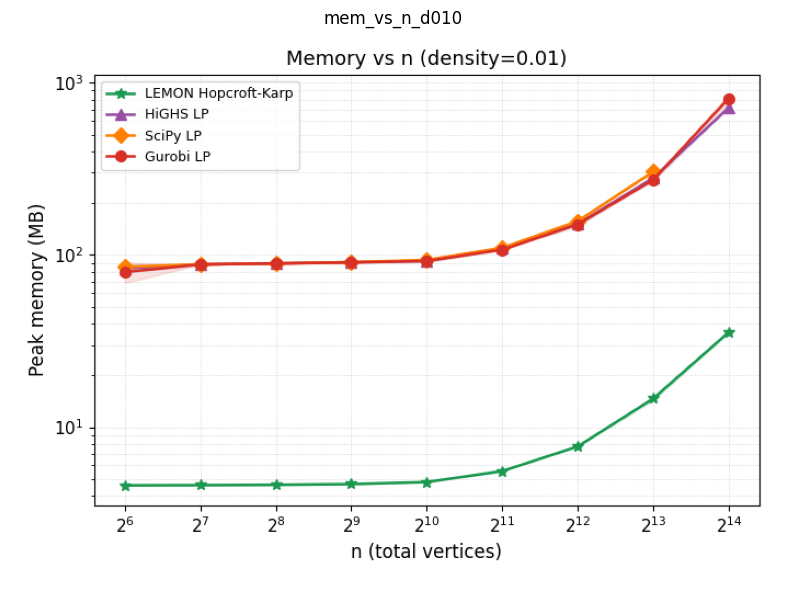

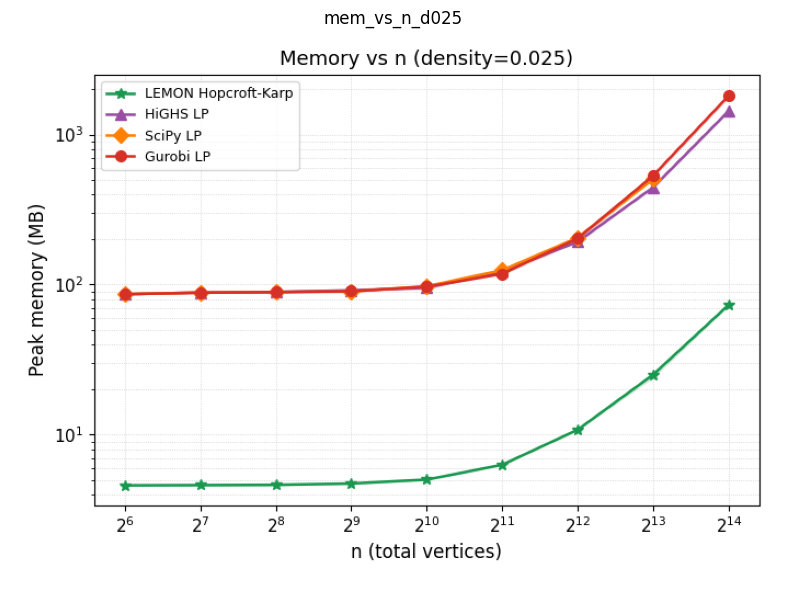

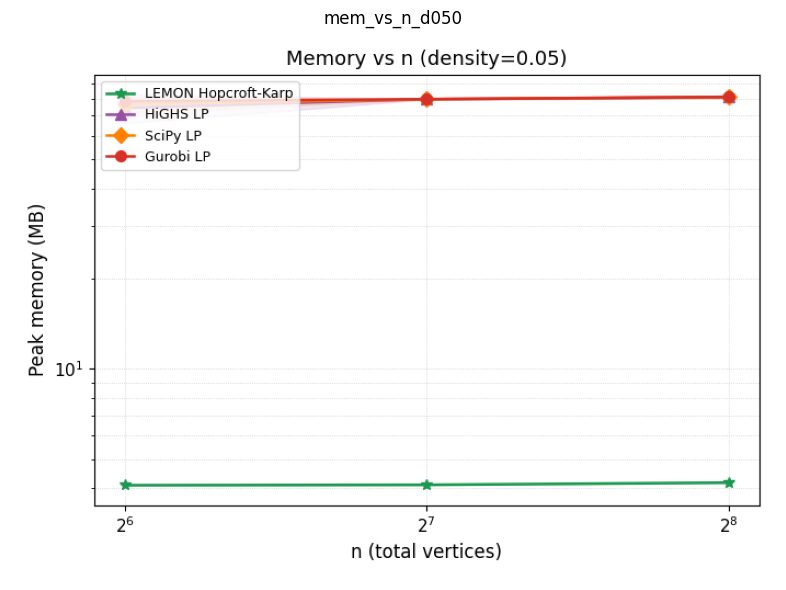

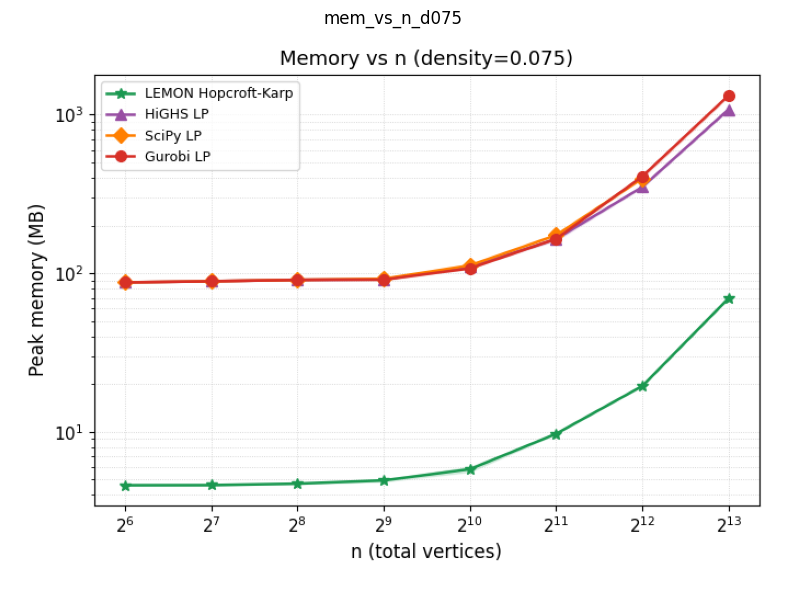

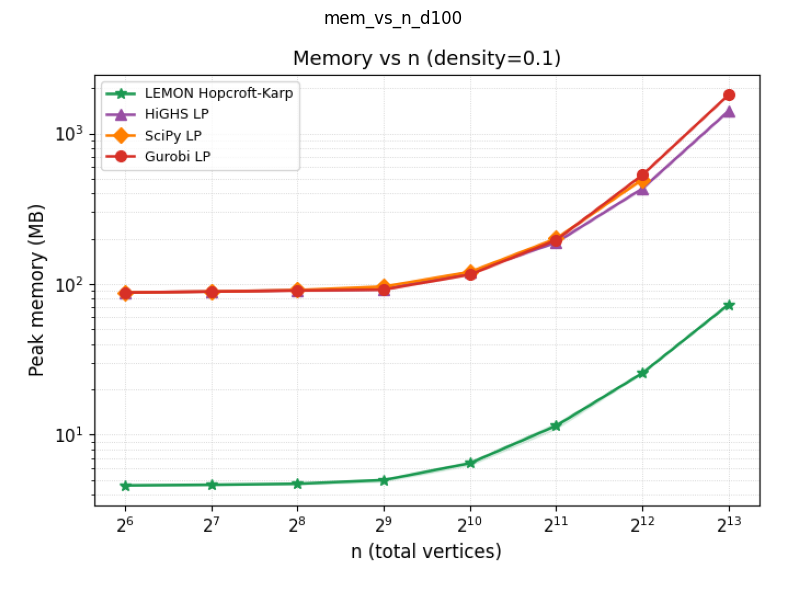

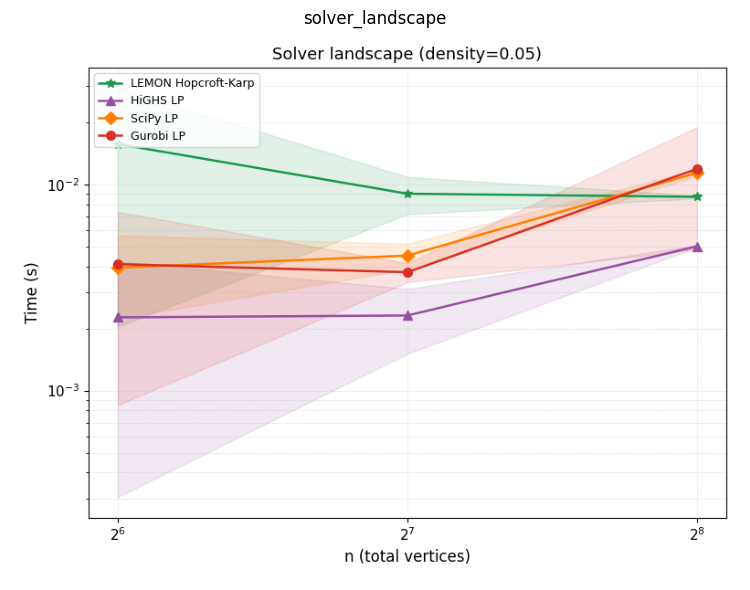

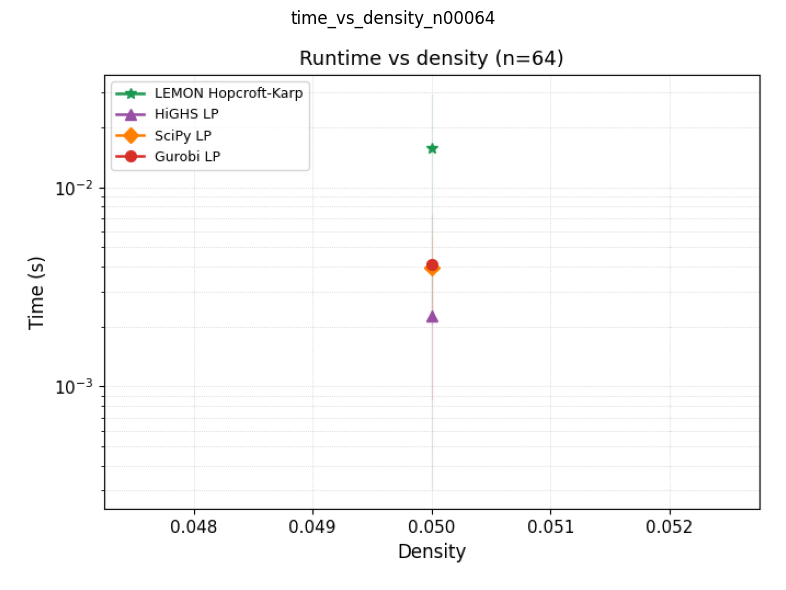

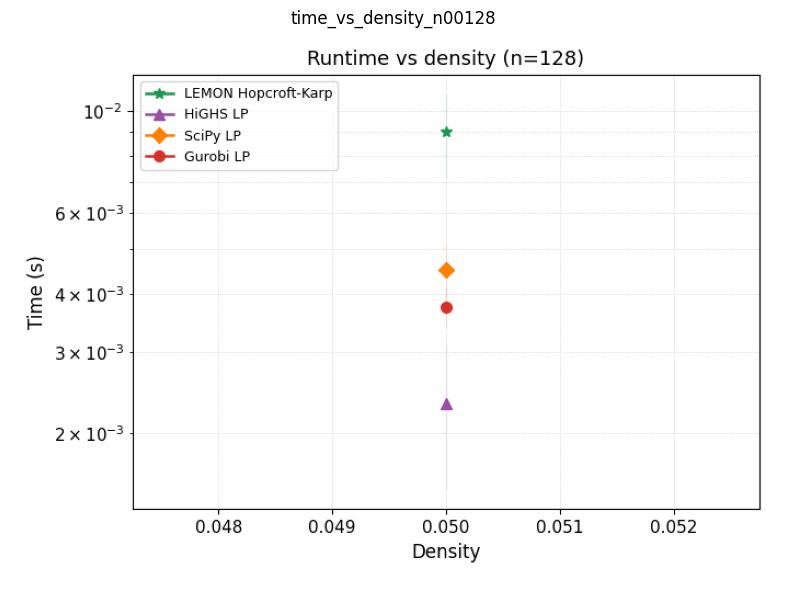

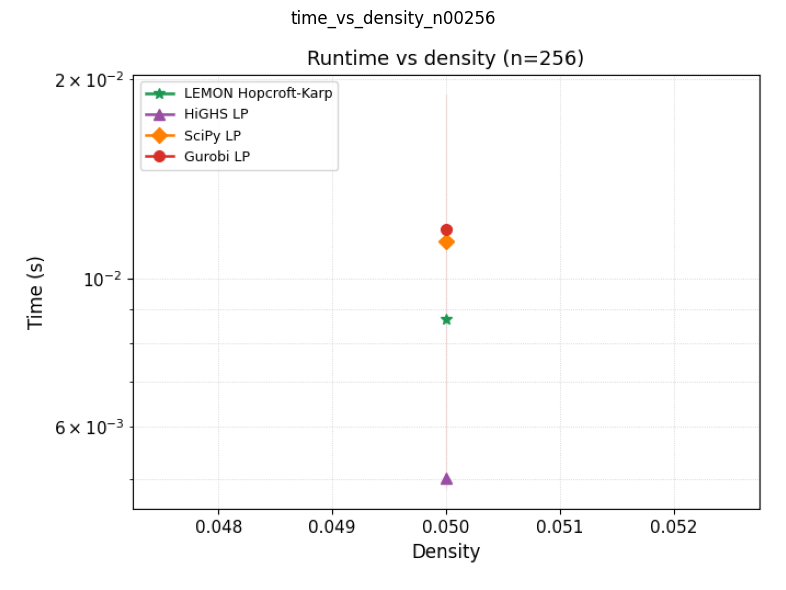

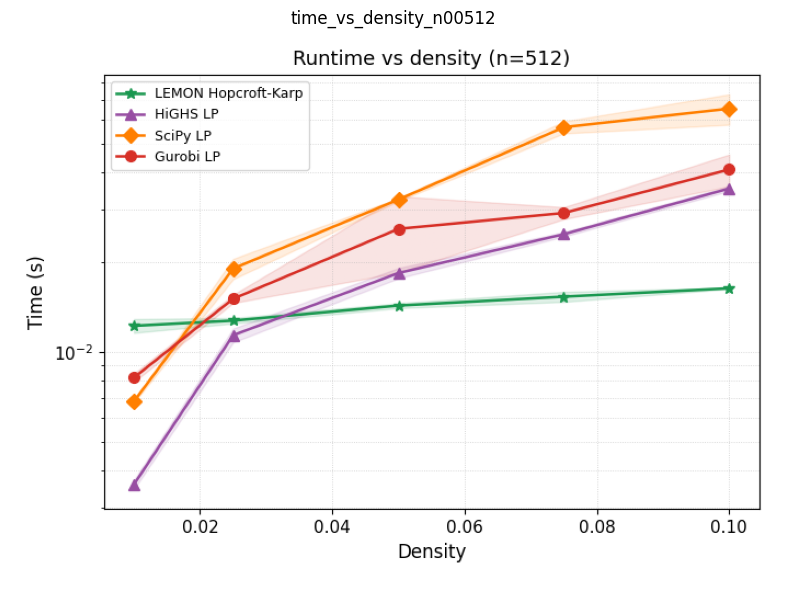

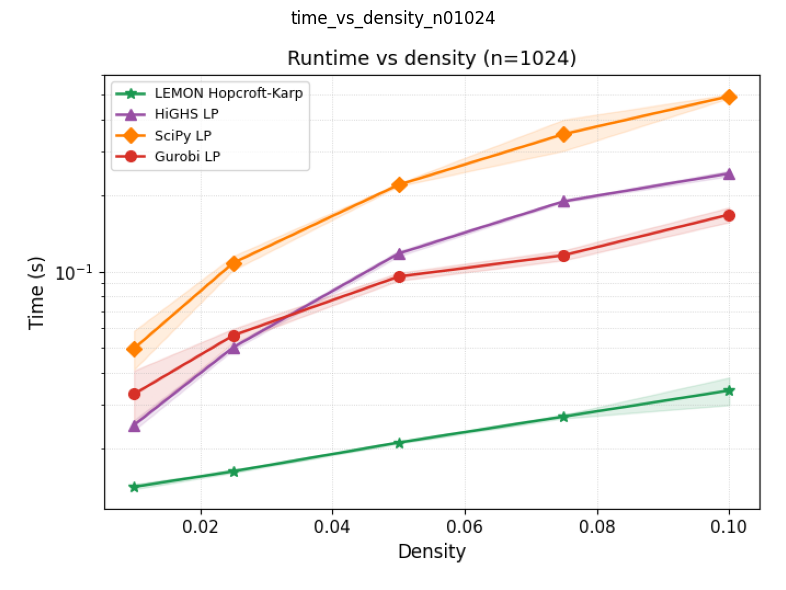

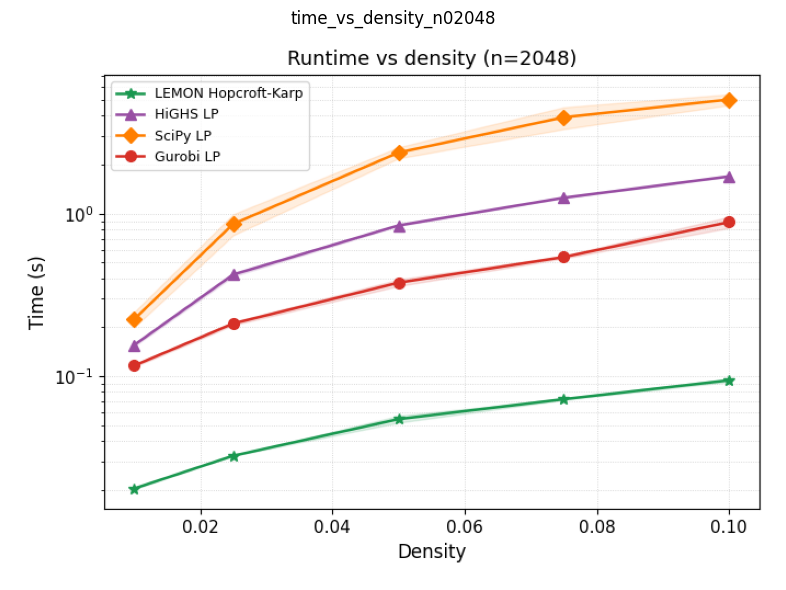

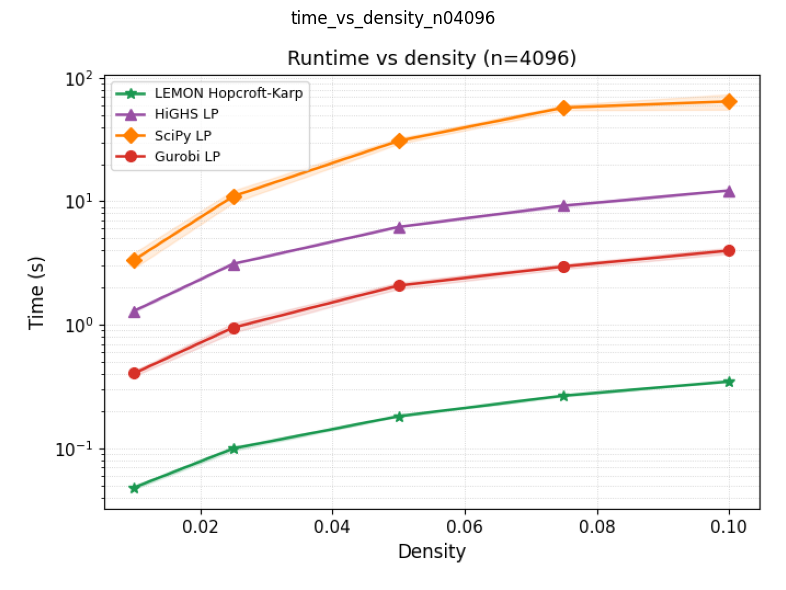

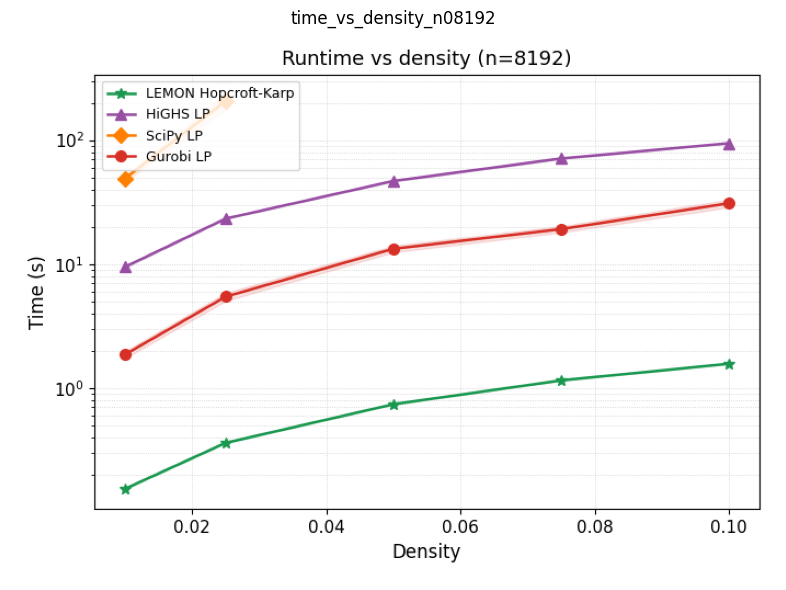

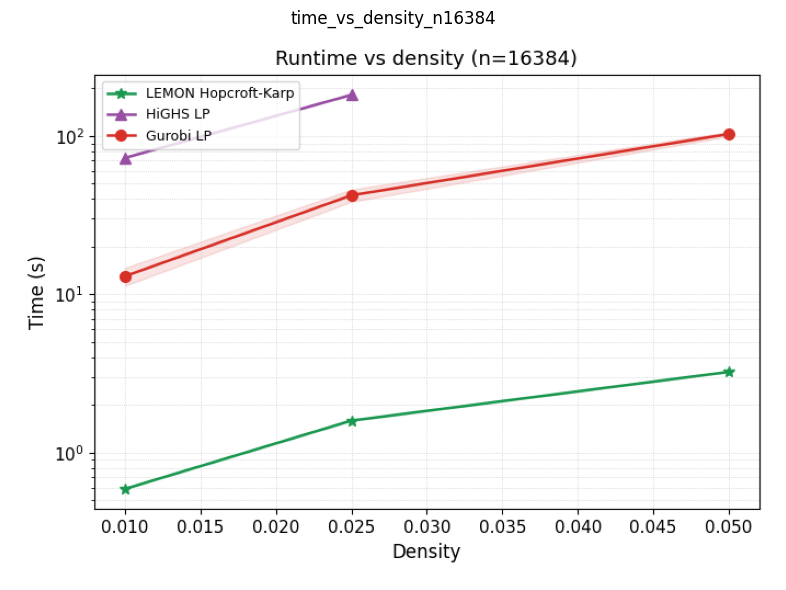

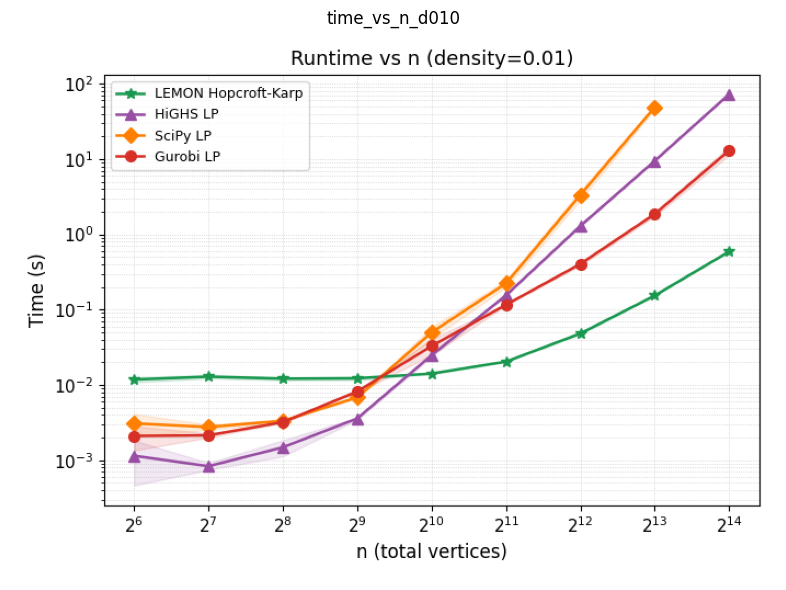

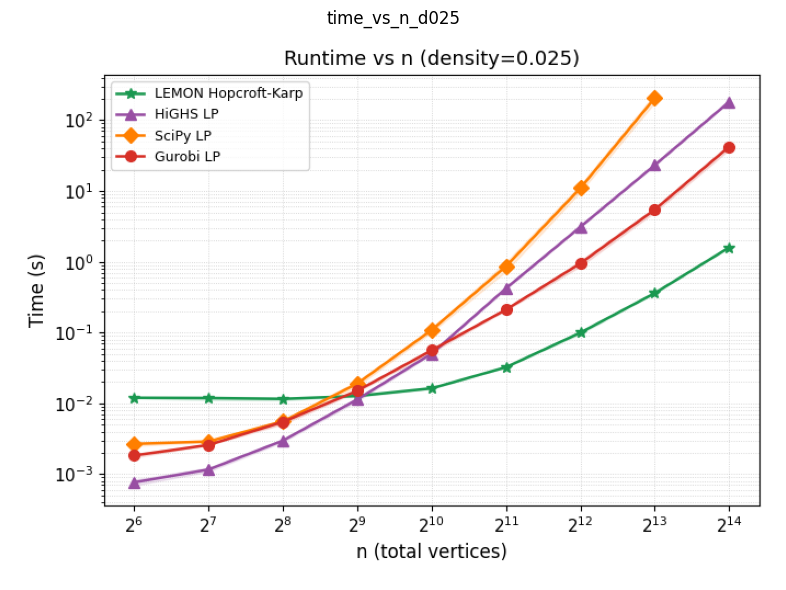

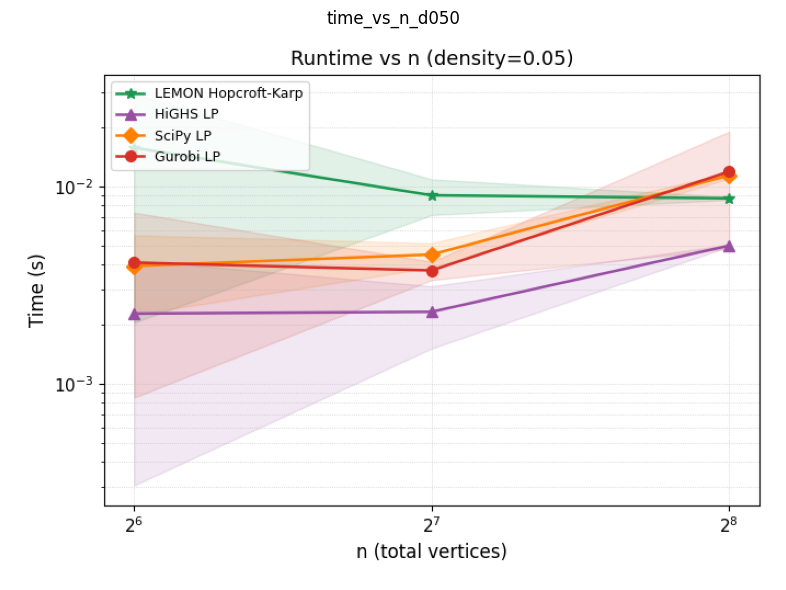

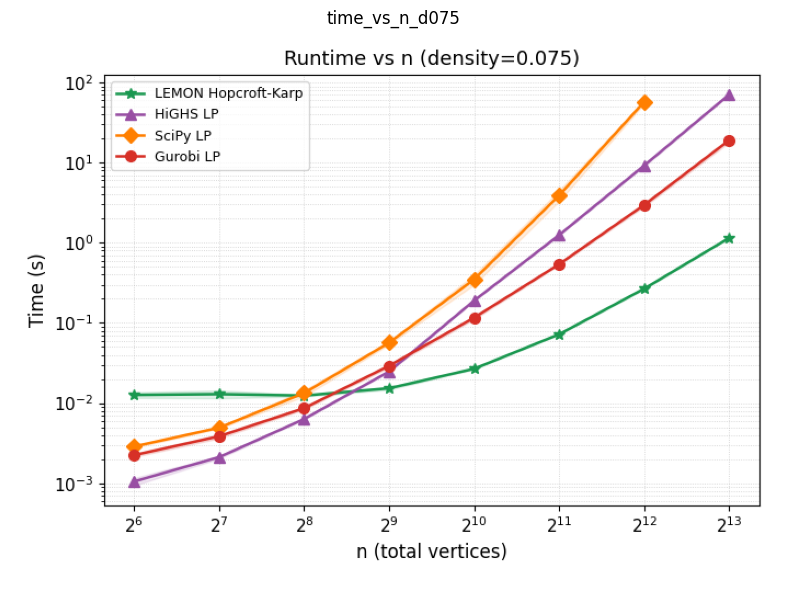

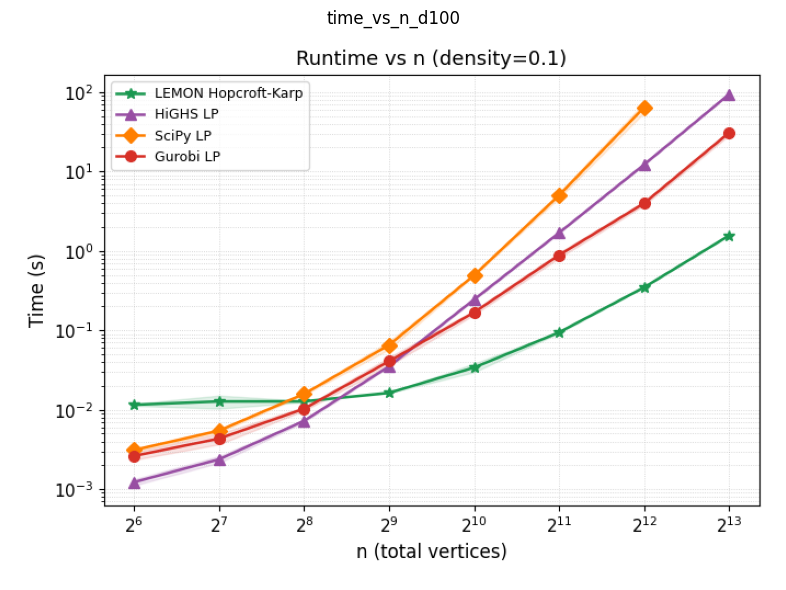

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pngs = sorted(FIGURES_DIR.glob("*.png"))
if not pngs:
    print("No PNG figures found")
else:
    for png in pngs:
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.imshow(mpimg.imread(str(png)))
        ax.axis("off")
        ax.set_title(png.stem)
        plt.tight_layout()
        plt.show()


## 9. Results Summary

In [10]:
import pandas as pd
from IPython.display import display

if not RESULTS_CSV.exists():
    print("No results.csv")
else:
    df = pd.read_csv(RESULTS_CSV)
    if "density" not in df.columns and "d" in df.columns:
        df = df.rename(columns={"d": "density"})

    print(f"Total rows: {len(df)}")

    print("\nStatus counts by solver:")
    display(df.groupby(["solver", "status"]).size().unstack(fill_value=0))

    df_ok = df[df["status"] == "optimal"]
    if not df_ok.empty:
        print("\nMean runtime (s) by solver and n:")
        display(df_ok.groupby(["solver", "n"])["time_seconds"].mean().unstack().round(4))

        print("\nMean peak memory (MB) by solver and n:")
        display(df_ok.groupby(["solver", "n"])["peak_memory_mb"].mean().unstack().round(1))

        print("\nFastest solver per graph:")
        best = df_ok.loc[df_ok.groupby(["n","density","seed"])["time_seconds"].idxmin(), "solver"].value_counts()
        display(best.rename("wins").to_frame())


Total rows: 36

Status counts by solver:


status,optimal
solver,
gurobi_lp,9
highs_lp,9
lemon_hk,9
scipy_lp,9



Mean runtime (s) by solver and n:


n,64,128,256
solver,,,
gurobi_lp,0.0041,0.0037,0.0119
highs_lp,0.0023,0.0023,0.0050
lemon_hk,0.0157,0.0090,0.0087
scipy_lp,0.0039,0.0045,0.0114



Mean peak memory (MB) by solver and n:


n,64,128,256
solver,,,
gurobi_lp,78.1,79.6,81.0
highs_lp,74.4,79.5,80.8
lemon_hk,4.1,4.1,4.2
scipy_lp,76.3,79.5,80.9



Fastest solver per graph:


,wins
solver,
highs_lp,9
